In [32]:
from datasets import load_dataset, load_dataset_builder, get_dataset_split_names, get_dataset_config_names
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ds_builder = load_dataset_builder("ylecun/mnist")

In [3]:
type(ds_builder)

datasets.packaged_modules.parquet.parquet.ParquetMnist

In [4]:
ds_builder.info.description

''

In [5]:
ds_builder.info.features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])}

In [6]:
ds_dict = load_dataset("ylecun/mnist")

In [7]:
type(ds_dict)

datasets.dataset_dict.DatasetDict

In [8]:
ds_dict

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [9]:
get_dataset_split_names("ylecun/mnist")

['train', 'test']

In [10]:
get_dataset_config_names("ylecun/mnist")

['mnist']

In [11]:
ds_train = load_dataset("ylecun/mnist", split="train")

In [25]:
ds_test = load_dataset('ylecun/mnist', split='test')

In [44]:
X_train = np.array(ds_train['image']) / 255.0
y_train = np.array(ds_train['label'])
X_test = np.array(ds_test['image']) / 255.0
y_test = np.array(ds_test['label'])

In [14]:
check = ds_train[1]['image']
print(type(check))
print(check)

<class 'PIL.PngImagePlugin.PngImageFile'>
<PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x1724E5AF070>


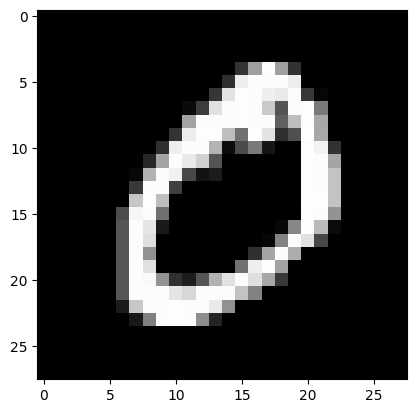

In [15]:
plt.imshow(check, cmap='gray')
plt.show()

In [50]:
model = models.Sequential()
model.add(layers.Conv2D(1, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))

c:\Users\klill\miniconda3\envs\male\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 1)      │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 676)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         6,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,780 (26.48 KB)

 Trainable params: 6,780 (26.48 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [53]:
history = model.fit(X_train, y_train, 
                    epochs=1,
                    validation_data=(X_test, y_test))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8697 - loss: 0.4535 - val_accuracy: 0.9172 - val_loss: 0.2910


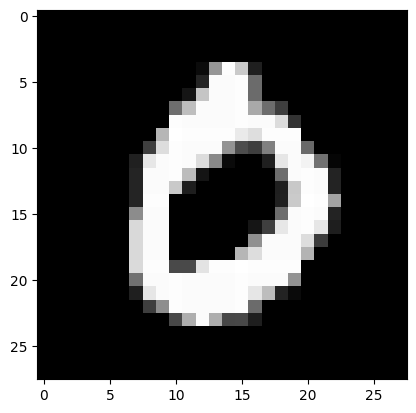

0

In [90]:
random_idx = 3
random_img = ds_test['image'][random_idx]
random_test = np.expand_dims(X_test[random_idx], axis=0)

plt.imshow(random_img, cmap='gray')
plt.show()

# type(random_test)
# random_test

prediction = model(random_test, training=False)
np.argmax(prediction)

In [95]:
model.export('first_model')

INFO:tensorflow:Assets written to: first_model\assets


INFO:tensorflow:Assets written to: first_model\assets


Saved artifact at 'first_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1590209157200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1590501217152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1590538272112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1590538259264: TensorSpec(shape=(), dtype=tf.resource, name=None)


### TensorFlow Automatic Differentiation tests

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [32]:
x = tf.Variable([3.0, 2.0])

with tf.GradientTape() as tape:
    y = x**2

dy_dx = tape.gradient(y, x)

dy_dx

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([6., 4.], dtype=float32)>

In [34]:
w = tf.Variable(tf.random.normal((3, 2)), name='w')
b = tf.Variable(tf.zeros(2, dtype=tf.float32), name='b')
x = [[1., 2., 3.]]

with tf.GradientTape(persistent=True) as tape:
  y = x @ w + b
  loss = tf.reduce_mean(y**2)

dl_dw, dl_db = tape.gradient(loss, [w, b])

dl_dw, dl_db

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-1.0885157e+01,  2.0616531e-02],
        [-2.1770313e+01,  4.1233063e-02],
        [-3.2655472e+01,  6.1849594e-02]], dtype=float32)>,
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([-10.885157  ,   0.02061653], dtype=float32)>)

In [47]:
layer = tf.keras.layers.Dense(2, activation='relu')
x = tf.constant([[1., 2., 3.]])

with tf.GradientTape() as tape:
  # Forward pass
  y = layer(x)
  loss = tf.reduce_mean(y**2)

# Calculate gradients with respect to every trainable variable
grad = tape.gradient(loss, layer.trainable_variables)

print(x.shape)
print(y)
print(loss)
print(grad)

(1, 3)
tf.Tensor([[0. 0.]], shape=(1, 2), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
[<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)>, <tf.Tensor: shape=(2,), dtype=float32, numpy=array([0., 0.], dtype=float32)>]


In [ ]:
x = tf.constant([1, 3.0])
with tf.GradientTape(persistent=False) as tape:
  tape.watch(x)
  y = x * x
  z = y * y

print(tape.gradient(z, x).numpy())  # [4.0, 108.0] (4 * x**3 at x = [1.0, 3.0])
print(tape.gradient(y, x).numpy())  # [2.0, 6.0] (2 * x at x = [1.0, 3.0])

[  4. 108.]
[2. 6.]


In [53]:
x = tf.Variable(2.0)
with tf.GradientTape(persistent=True) as tape:
  y1 = 1 / x
  y0 = x**2
  

print(tape.gradient(y0, x).numpy())
print(tape.gradient(y1, x).numpy())

4.0
-0.25


In [ ]:
x = tf.constant(10)     # returns None
x = tf.constant(10.)    # returns 20.

with tf.GradientTape() as g:
  g.watch(x)
  y = x * x

print(g.gradient(y, x))

tf.Tensor(20.0, shape=(), dtype=float32)


In [57]:
x0 = tf.Variable(3.0)
x1 = tf.Variable(0.0)

with tf.GradientTape() as tape:
  # Update x1 = x1 + x0.
  x0.assign_add(x1)
  # The tape starts recording from x1.
  y = x0**2   # y = (x1 + x0)**2

# This doesn't work.
print(tape.gradient(y, x0))   #dy/dx0 = 2*(x1 + x0)

tf.Tensor(6.0, shape=(), dtype=float32)


In [63]:
@tf.function
def unused_return_eager(x):
  # Get index 1 will fail when `len(x) == 1`
  tf.gather(x, [1]) # unused 
  return x

try:
  print(unused_return_eager(tf.constant([0.0])))
except tf.errors.InvalidArgumentError as e:
  # All operations are run during eager execution so an error is raised.
  print(f'{type(e).__name__}: {e}')

tf.Tensor([0.], shape=(1,), dtype=float32)


In [68]:
@tf.function
def a_function_with_python_side_effect(x):
  print("Tracing!") # An eager-only side effect.
  return x * x + tf.constant(2)

# This is traced the first time.
# The second time through, you won't see the side effect.
print(a_function_with_python_side_effect(tf.constant(2)))
print(a_function_with_python_side_effect(tf.constant(3)))

# This retraces each time the Python argument changes,
# as a Python argument could be an epoch count or other
# hyperparameter.
print(a_function_with_python_side_effect(2))
print(a_function_with_python_side_effect(3))

Tracing!
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(11, shape=(), dtype=int32)
Tracing!
tf.Tensor(6, shape=(), dtype=int32)
Tracing!
tf.Tensor(11, shape=(), dtype=int32)


### tf.Module

In [69]:
class MyModule(tf.Module):
  def __init__(self, value):
    self.weight = tf.Variable(value)

  @tf.function
  def multiply(self, x):
    return x * self.weight
  
mod = MyModule(3)
mod.multiply(tf.constant([1, 2, 3]))

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([3, 6, 9], dtype=int32)>

In [70]:
save_path = './saved'
tf.saved_model.save(mod, save_path)

INFO:tensorflow:Assets written to: ./saved\assets


INFO:tensorflow:Assets written to: ./saved\assets
